# Import Libraries and read data 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('raw_data.csv')

In [ ]:
df.head()

,Timestamp,age,sleep_duration,water_intake,stress,screentime,illness
0,23/03/2026 14:16:37,19,6-7,2.0,3,10.0,Yes
1,23/03/2026 14:20:19,20,5-6,3.0,6,5.0,No
2,23/03/2026 14:21:07,20,6-7,2.5,3,1.0,No
3,23/03/2026 14:22:47,20,5-6,3.0,9,4.0,Yes
4,23/03/2026 14:23:46,19,5-6,2.0,6,4.0,Yes


# Modify colomns and roms of datasets

In [ ]:
#drop Timestamp columns
df.drop(['Timestamp'], axis=1, inplace=True)

In [ ]:
# Convert yes and no in column illness to 1 and 0
df['illness'] = df['illness'].map({'Yes': 1, 'No': 0})


In [ ]:
df['sleep_duration'] = df['sleep_duration'].map({'<3': 2.5, '3-4':3.5,'4-5':4.5,'5-6':5.5,'6-7':6.5,'7-8':7.5,'>8':8.5})

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40 non-null     int64  
 1   sleep_duration  40 non-null     float64
 2   water_intake    40 non-null     float64
 3   stress          40 non-null     int64  
 4   screentime      40 non-null     float64
 5   illness         40 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 2.0 KB


In [ ]:
df.head()

,age,sleep_duration,water_intake,stress,screentime,illness
0,19,6.5,2.0,3,10.0,1
1,20,5.5,3.0,6,5.0,0
2,20,6.5,2.5,3,1.0,0
3,20,5.5,3.0,9,4.0,1
4,19,5.5,2.0,6,4.0,1


# Data preproccessing

In [ ]:

# Check for missing values
df.isnull().sum()

age               0
sleep_duration    0
water_intake      0
stress            0
screentime        0
illness           0
dtype: int64

In [ ]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

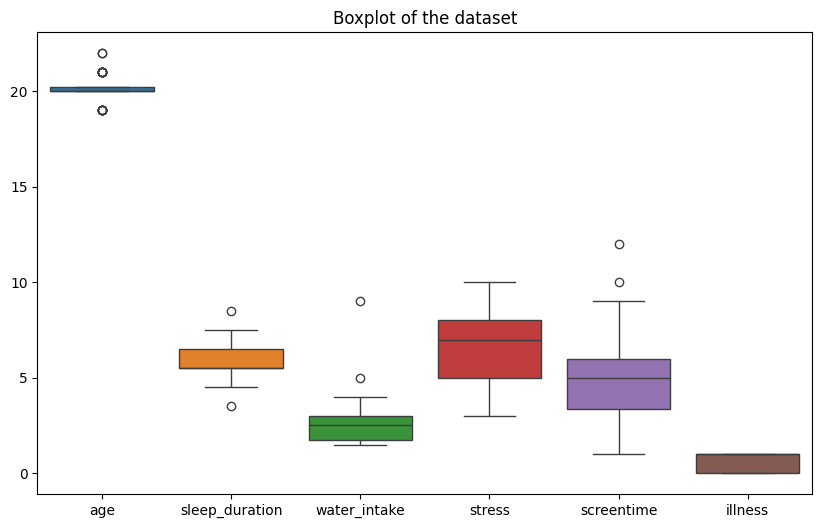

In [ ]:
# check for outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()
# remove outliers in columns sleep_duration and screentime using IQR method
Q1 = df[['sleep_duration','water_intake', 'screentime']].quantile(0.25)
Q3 = df[['sleep_duration','water_intake', 'screentime']].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[['sleep_duration','water_intake', 'screentime']] < (Q1 - 1.5 * IQR)) | (df[['sleep_duration','water_intake', 'screentime']] > (Q3 + 1.5 * IQR))).any(axis=1)]



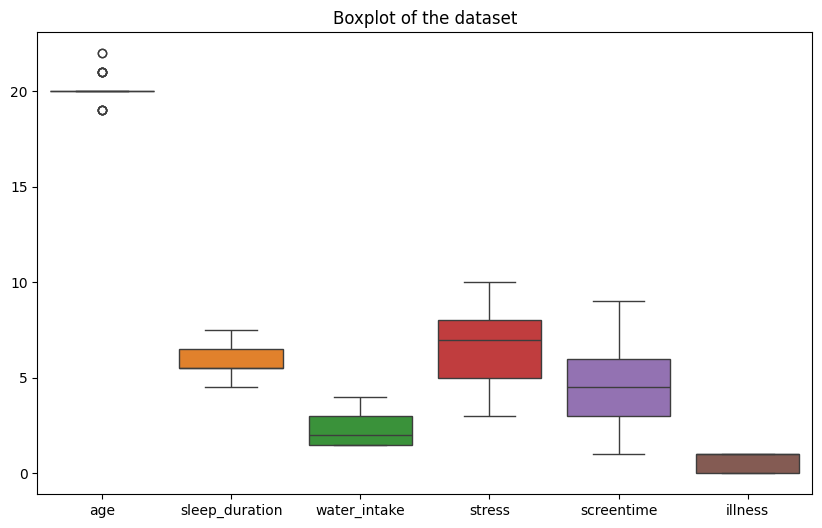

In [ ]:
# check for outliers and remove them 
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()

In [ ]:
# Shape after removing outliers
df.shape

(34, 6)

In [ ]:
# desciptive statistics
df.describe()

,age,sleep_duration,water_intake,stress,screentime,illness
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,20.147059,6.088235,2.288235,6.676471,4.764706,0.529412
std,0.743960,0.856973,0.700980,1.700634,2.157563,0.506640
min,19.000000,4.500000,1.500000,3.000000,1.000000,0.000000
25%,20.000000,5.500000,1.500000,5.000000,3.000000,0.000000
50%,20.000000,5.500000,2.000000,7.000000,4.500000,1.000000
75%,20.000000,6.500000,3.000000,8.000000,6.000000,1.000000
max,22.000000,7.500000,4.000000,10.000000,9.000000,1.000000


# EDA

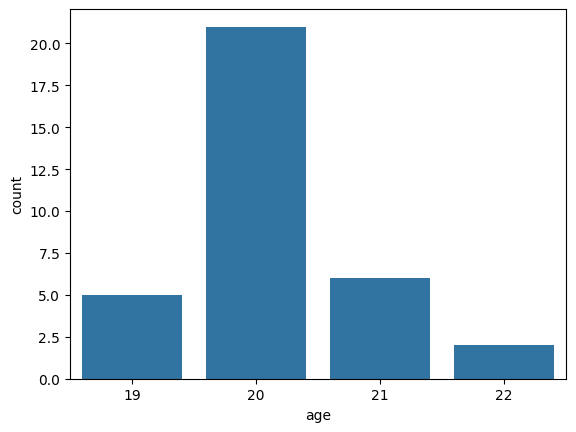

In [ ]:
# age distribution histogram bin 19,20,21,22,23
sns.barplot(x=df['age'].value_counts().index, y=df['age'].value_counts())
plt.show()

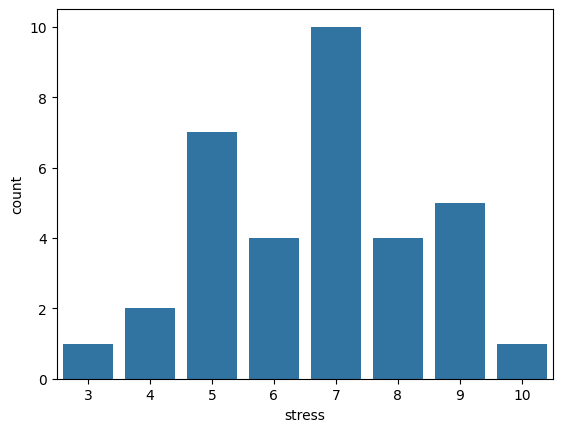

In [ ]:
# ​Count Plots (Bar Charts) of stress
sns.barplot(x=df['stress'].value_counts().index, y=df['stress'].value_counts())
plt.show()

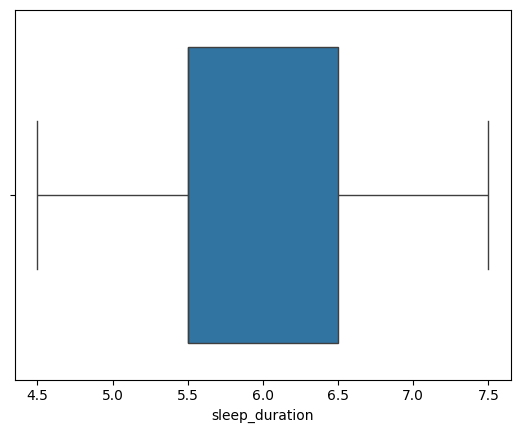

In [ ]:
# boxplots sleep_duration
sns.boxplot(x=df['sleep_duration'])
plt.show()

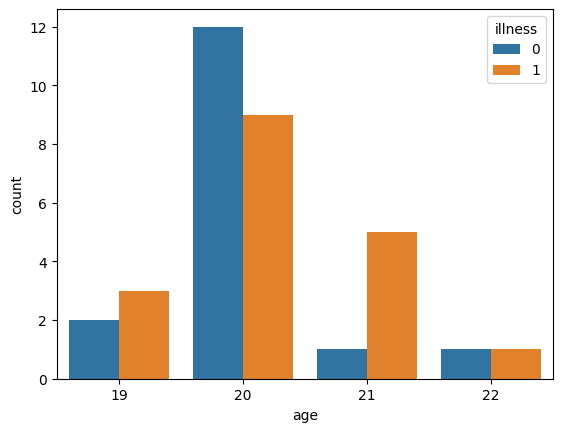

In [ ]:
# group barchart : age vs illness (1 and 0)
sns.countplot(x='age', hue='illness', data=df)
plt.show()

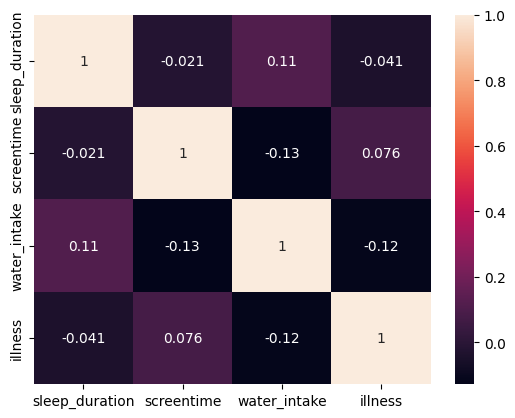

In [ ]:
# heatmap sleep_duration, screentime, water_intake vs. illness
sns.heatmap(df[['sleep_duration', 'screentime', 'water_intake', 'illness']].corr(), annot=True)
plt.show()

# Build model 

In [ ]:
# split data 80 for training and 20 for testing
data = df.to_numpy()
X = data[:,:5]
y = data[:,5]

# Split into training and testing sets
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(27, 5)
(7, 5)
(27,)
(7,)


In [ ]:
# Feature scaling
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)
X_scaled = (X_train - mean_X_train) / std_X_train

X_new = np.concatenate((np.ones((X_scaled.shape[0], 1)), X_scaled), axis=1)


In [ ]:
# Logistic Regresstion
def hypothesis(theta, X):
    return np.matmul(X, theta)

def sigmoid(z):
    return 1 / (1+ np.exp(-z))

def cost(X, y, theta):
    z = hypothesis(theta, X)
    h = sigmoid(z)
    m = len(y)
    c = (1/m) * ((-y*np.log(h) - (1-y)*np.log(1-h)).sum())
    return c

def gradient(X, y, theta):
    z = hypothesis(theta, X)
    h = sigmoid(z)
    m = len(y)
    grad = (1/m) * np.dot(X.T, (h-y))
    return grad


In [ ]:
# make sure target vectors are column vectors
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# training
theta = np.zeros((X_new.shape[1], 1))
lr = 0.1

for i in range(1, 1001):
    z = hypothesis(theta, X_new)
    h = sigmoid(z)
    c = cost(X_new, y_train, theta)
    grad = gradient(X_new, y_train, theta)

    theta = theta - lr * grad

    print(f'Iteration: {i}, Cost: {c:.4f}')

Iteration: 1, Cost: 0.6931
Iteration: 2, Cost: 0.6873
Iteration: 3, Cost: 0.6817
Iteration: 4, Cost: 0.6765
Iteration: 5, Cost: 0.6715
Iteration: 6, Cost: 0.6669
Iteration: 7, Cost: 0.6624
Iteration: 8, Cost: 0.6583
Iteration: 9, Cost: 0.6543
Iteration: 10, Cost: 0.6506
Iteration: 11, Cost: 0.6471
Iteration: 12, Cost: 0.6437
Iteration: 13, Cost: 0.6406
Iteration: 14, Cost: 0.6376
Iteration: 15, Cost: 0.6347
Iteration: 16, Cost: 0.6320
Iteration: 17, Cost: 0.6294
Iteration: 18, Cost: 0.6270
Iteration: 19, Cost: 0.6247
Iteration: 20, Cost: 0.6225
Iteration: 21, Cost: 0.6204
Iteration: 22, Cost: 0.6184
Iteration: 23, Cost: 0.6165
Iteration: 24, Cost: 0.6147
Iteration: 25, Cost: 0.6130
Iteration: 26, Cost: 0.6114
Iteration: 27, Cost: 0.6098
Iteration: 28, Cost: 0.6083
Iteration: 29, Cost: 0.6069
Iteration: 30, Cost: 0.6055
Iteration: 31, Cost: 0.6042
Iteration: 32, Cost: 0.6030
Iteration: 33, Cost: 0.6018
Iteration: 34, Cost: 0.6006
Iteration: 35, Cost: 0.5996
Iteration: 36, Cost: 0.5985
I

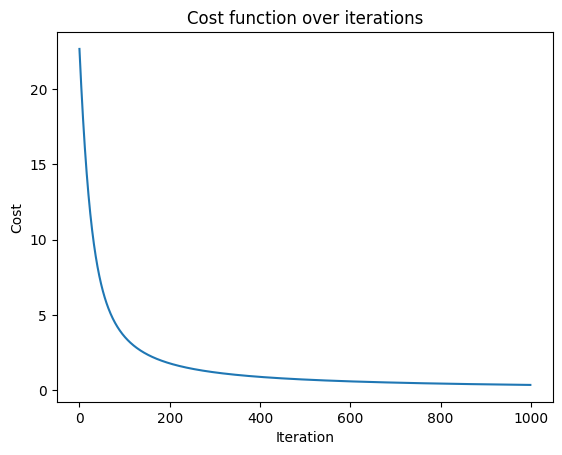

In [ ]:
# plot cost function
costs = []
for i in range (1, 1001):
    z = hypothesis(theta, X_new)
    h = sigmoid(z)
    c = cost(X_new, y, theta)
    grad = gradient(X_new, y, theta)

    theta = theta - lr*grad

    costs.append(c)
plt.plot(costs)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost function over iterations')
plt.show()

# Evaluation and result

In [ ]:

# find accuracy 
h = sigmoid(hypothesis(theta, X_new))
y_pred = h.copy()
y_pred[h>=0.5] = 1
y_pred[h<0.5] = 0
accuracy = np.mean(y_pred == y_train)
print(f"Accuracy : {accuracy * 100: .2f}%")

Accuracy :  50.54%


In [ ]:
# find precision, recall, f1-score
TP = np.sum((y_pred == 1) & (y_train == 1))
FP = np.sum((y_pred == 1) & (y_train == 0))
TN = np.sum((y_pred == 0) & (y_train == 0))
FN = np.sum((y_pred == 0) & (y_train == 1))
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Precision: 0.5926
Recall: 0.5294
F1 Score: 0.5592


: 